## __Sentiment Analysis Project USing NLTK and NLP PipeLine__

In [2]:
DATASET_CREDIT = 'https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv'
# taken From Kaggle IMDB Dataset of 50K Movie Reviews

In [109]:
import pandas as pd
import numpy as np
# TF-IDF vectorizer 
from sklearn.feature_extraction.text import TfidfVectorizer

# train test SPlit 
from sklearn.model_selection import train_test_split

! pip install nltk
import nltk
# nltk librabry for performing NLP Tasks (tokenization, stopword removal, stemming, lemmatization)
import string 
# string is a built-in Python library that contains special character sets.
# like string.punctuation

from nltk.corpus import stopwords
# importing stopwords

from nltk.stem import WordNetLemmatizer
#Lemmatization converts a word to its base/root form.


# Required Models
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ensemble methods
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
! pip install xgboost
from xgboost import XGBClassifier
# model Evaluation metries
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 11.8 MB/s eta 0:00:09
   - -------------------------------------- 4.5/101.7 MB 12.2 MB/s eta 0:00:08
   -- ------------------------------------- 6.8/101.7 MB 11.7 MB/s eta 0:00:09
   --- ------------------------------------ 10.0/101.7 MB 12.2 MB/s eta 0:00:08
   ---- ----------------------------------- 11.5/101.7 MB 11.3 MB/s eta 0:00:08
   ---- ----------------------------------- 11.8/101.7 MB 10.7 MB/s eta 0:00:09
   ---- ----------------------------------- 12.3/101.7 MB 8.8 MB/s eta 0:00:11
   ----- ---------------------------------- 12.8/101.7 MB 7.8 MB/s eta 0:00:12
   ----- ---------------------------------- 13.6/101.7 MB 7.1 MB/s eta 0:00:13
   ----- ---------------------------------- 14.4/101.7 MB 6.8 MB/s eta 0:00:13
   ----- ---------------------------------- 14.9/101.7 MB 6.4 MB/s eta 0:00:14
   ------ --------------------------------- 15.7/101.7 MB


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"

df = pd.read_csv(url)


In [4]:
# saving the dataset Locally
df.to_csv("imbd_Dataset.csv",index=False)

In [5]:
df = pd.read_csv("imbd_Dataset.csv")

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.shape

(50000, 2)

In [8]:
df['sentiment'].value_counts()
# balanced Dataset


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
# First Review 
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

__many unnecessary things such as: html tags , punctuation (! , . ?),stopwords (the, is, and),special characters,extra spaces,uppercase letters__
#### Basic Text Cleaning (Natural Language Preprocessing)

- removing Html tags
- Convert text → lowercase
- Contraction Expansion
- Remove punctuation
- Remove special characters
- Remove stopwords
- Tokenization
- Lemmatization

In [12]:
import nltk
# nltk librabry for performing NLP Tasks (tokenization, stopword removal, stemming, lemmatization)
import string 
# string is a built-in Python library that contains special character sets.
# like string.punctuation

from nltk.corpus import stopwords
# importing stopwords

from nltk.stem import WordNetLemmatizer
#Lemmatization converts a word to its base/root form.

In [13]:
# download required data for Removing stopwords and Net/base Words
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
# creating stopword list 
stop_words = stopwords.words('english')

In [15]:
# stop_words
print(stop_words)
# now we can remove these Stopwords from the Reviews easily by using this list later

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [16]:
# Creating lemmatizer Object for lemmatizing the Reviews
"""Lemmatization converts a word to its base/root form.
Example:
running -	run
better -	good
movies -	movie"""

lemmatizer = WordNetLemmatizer()


In [17]:

a = lemmatizer.lemmatize('running')
b = lemmatizer.lemmatize('better')
c = lemmatizer.lemmatize('movies')

print(a,b,c)

running better movie


__We can observe the Lemmatizer do not lemmatize perfectly to words like 'running' , 'better'__
#### __Because By default, WordNetLemmatizer assumes every word is a NOUN.__
- Internally it behaves as lemmatizer.lemmatize(word, pos="n")
- but in actual datasets we have to check POS tag for each word to correctly lemmatize the words
- so whenever the words are adjectives or verbs it does not reduce it properly because it assumes noun

In [18]:
# to do that we use pos_tag from nltk
from nltk import pos_tag

words=['running','better','movies']

position_words = pos_tag(words)
print(position_words)

[('running', 'VBG'), ('better', 'JJR'), ('movies', 'NNS')]


#### But WordNetLemmatizer expects:
- n -	noun (wordnet.NOUN)
- v - verb (wordnet.VERB)
- a - adjective (wordnet.ADJ)
- r -	adverb (wordnet.ADV)

In [19]:
# we have to convert this tag manually 
from nltk.corpus import wordnet

# cREATING FUNCTION FOR gETTING THE TAG 
def get_wordnet_tag(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
  

In [20]:
lemmatized_words = []

# WE ARE JUST TAKING EACH wORD AND ITS CORRESPONDING TAG FROM POS_TAG AND LEMMATIZING IT.
for word ,tag in position_words:
    tag = get_wordnet_tag(tag)
    new_word = lemmatizer.lemmatize(word,tag)
    lemmatized_words.append(new_word)

In [21]:
print(lemmatized_words)
# now we can observe the Words are properly Lemmatized....
# WE JUST HAVE COMPLETED THE WAY OF TAGGING + LEMMATIZING 

['run', 'good', 'movie']


### __Now Lets apply all the pipeline of NLP on FIrst Review__

- removing Html tags
- Convert text → lowercase
- Contraction Expansion
- Remove punctuation
- Remove special characters
 - Tokenization
- Remove stopwords
- Lemmatization

In [22]:
df.head(2)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive


In [23]:
First_Review = df['review'][0]
First_Review

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [24]:
First_sentiment = df['sentiment'][0]
First_sentiment

'positive'

### 1. Removing the Html Tags 

In [25]:
# Removing the Html Tags 
# this can be done using the Regex 
import re

# first we will Create the Regular Expression OBject for the pattern of HTML Tags
html_pattern = re.compile(r'<.*?>')

# substitute the html text with  ("") nothing in text
Cleaned_Text = re.sub(html_pattern,' ',First_Review)
print(Cleaned_Text)


One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.  The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.  It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.  I would say the main appeal of the show is due to the fact that it goes where other sho

#### 2. LowerCase text

In [26]:
Cleaned_Text = Cleaned_Text.lower()

In [27]:
print(Cleaned_Text)

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.  the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.  it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.  i would say the main appeal of the show is due to the fact that it goes where other sho

#### 3.Contraction Expansion
__A contraction is a shortened form of two words joined with an apostrophe.__

- you'll - you will
- can't - 	can not
- don't	- do not

__If we remove punctuation first like can't -> cant we can never get the exact meaning of text which is  *can not* , so this step is important to done before Punctuation removal__

In [28]:
! pip install contractions


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import contractions

Expaned_text = contractions.fix(Cleaned_Text )
print(Expaned_text)

one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.  the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.  it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. them city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.  i would say the main appeal of the show is due to the fact that it goes where other

#### 4. Removing Punctuation
__. , ! ? : ; ' " - ( )__

In [30]:
# this can be DOne using String Library of Python
import string 

punctuation = string.punctuation
print(punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [31]:
#Create a translation table that deletes all punctuation characters
table = str.maketrans('','',punctuation)
print(table)
# ASCII values of Punctuation Letters -> None (it means to delete them)

{33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}


In [32]:
"""Python translate() method is used to transform a string by replacing or removing specific
characters based on a translation table. This table is created using the str.maketrans() method."""
new_Text = Expaned_text.translate(table)
print(new_Text)

one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked they are right as this is exactly what happened with me  the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word  it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda them city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away  i would say the main appeal of the show is due to the fact that it goes where other shows would not dare forget p

#### 5. Remove special characters
__@ # $ % ^ & * _ + = ~ ` | \ /__

In [33]:
# we can use Regular Expressions for this

# Not  NOT (a-z, A-Z, 0-9, _)
pattern1 = r'[^A-Za-z0-9\s_]'
pattern2 = r'\W' # non Alphanumeric Match 

pattern = re.compile(pattern2)
Cleaned_Text = re.sub(pattern2,' ',new_Text)
print(Cleaned_Text)

one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked they are right as this is exactly what happened with me  the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word  it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda them city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away  i would say the main appeal of the show is due to the fact that it goes where other shows would not dare forget p

#### 6. Tokenization

__Tokenization means breaking a sentence into smaller pieces called tokens.
Usually these tokens are words.__

In [34]:
Tokens = Cleaned_Text.split()
print(Tokens)

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', 'you', 'will', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go', 'trust', 'me', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', 'sex', 'or', 'violence', 'its', 'is', 'hardcore', 'in', 'the', 'classic', 'use', 'of', 'the', 'word', 'it', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'it', 'focuses', 'mainly', 'on', 'emerald', 'city', 'an', 'experimental', 'section', 'of', 'the', 'prison', 'where', 'all', 'the', 'cel

#### 7. Remove stopwords
__Stopwords are very common words in a language that usually do not carry important meaning.__
- the
- is
- and
- in etc.
  
__But some of Stopwords Actually carry the Important meaning (generally negative Words)__
- not
- no
- never
- nor

__Because this can cahnge the Sentiment from Postive -> negative__

In [35]:
from nltk.corpus import stopwords
nltk.download()
# from the window appearing download the corpus -> stopwords 

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [36]:
stopwords = stopwords.words('english')

In [37]:
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [38]:
# From above List we will remove  not, no, never, nor
Stopwords_set = set(stopwords)
ActualStopwords = Stopwords_set - {'not','no','never','nor'}

In [39]:
print(ActualStopwords)

{'does', 'being', 'whom', "shouldn't", 'ours', "i've", 'themselves', 'you', 'in', 'off', 'if', "i'd", "she'd", 'few', 'our', "hasn't", 'we', 'where', 'theirs', 'don', 'after', 'them', 'some', 'ma', 'own', 'through', 'yourself', "wouldn't", "he'd", "we'll", "hadn't", 'these', "we've", "that'll", 'out', 'what', 'on', "i'll", 'into', 'then', "mustn't", 'under', 'before', "needn't", 'aren', 'have', 'are', 'had', 're', 've', 'were', 'an', "she's", 'because', "it'd", 'only', 'shan', 'didn', 'all', 'himself', 'him', "they're", 'up', 'now', 'which', 'wouldn', "won't", 'or', 'by', 'they', "don't", 'about', 'over', 'doing', "didn't", 'his', 'mustn', 'm', "he'll", 'further', 'between', 'below', "we'd", 'been', "wasn't", 'has', 'above', 'against', 'so', "they'll", "shan't", 'won', 'did', 'most', 'her', 'their', 'she', 'same', 'ain', "you'd", 'but', 'just', 'yours', "i'm", 'when', "it's", "you've", 'do', 'down', 'will', 'as', 't', "they'd", 'why', 'shouldn', 'each', 'y', "you're", 'again', 'once', 

In [40]:
# now removing the Stopwords from Tokens 
Token = [word for word in Tokens if word not in ActualStopwords]
print(Token)


['one', 'reviewers', 'mentioned', 'watching', '1', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'not', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'no', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'word', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'not', 'high', 'agenda', 'city', 'home', 'manyaryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', 'moreso', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'away', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'would', 'not', 'dare', 'forget', 'pretty', 'pictures', 'painted', 'mainstre

#### 8. Lemmatization
__we have discussed this above__

In [41]:
position_tag = pos_tag(list(Token))
print(position_tag)

[('one', 'CD'), ('reviewers', 'NNS'), ('mentioned', 'VBD'), ('watching', 'VBG'), ('1', 'CD'), ('oz', 'JJ'), ('episode', 'NN'), ('hooked', 'VBD'), ('right', 'RB'), ('exactly', 'RB'), ('happened', 'VBD'), ('first', 'JJ'), ('thing', 'NN'), ('struck', 'VBD'), ('oz', 'JJ'), ('brutality', 'NN'), ('unflinching', 'VBG'), ('scenes', 'NNS'), ('violence', 'NN'), ('set', 'VBN'), ('right', 'RB'), ('word', 'NN'), ('go', 'VB'), ('trust', 'IN'), ('not', 'RB'), ('show', 'VB'), ('faint', 'NN'), ('hearted', 'VBN'), ('timid', 'JJ'), ('show', 'NN'), ('pulls', 'VBZ'), ('no', 'DT'), ('punches', 'NNS'), ('regards', 'NNS'), ('drugs', 'NNS'), ('sex', 'NN'), ('violence', 'NN'), ('hardcore', 'NN'), ('classic', 'JJ'), ('use', 'NN'), ('word', 'NN'), ('called', 'VBN'), ('oz', 'NN'), ('nickname', 'NN'), ('given', 'VBN'), ('oswald', 'JJ'), ('maximum', 'JJ'), ('security', 'NN'), ('state', 'NN'), ('penitentary', 'JJ'), ('focuses', 'NNS'), ('mainly', 'RB'), ('emerald', 'VBP'), ('city', 'NN'), ('experimental', 'JJ'), ('se

In [42]:
def get_wordnet_tag(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
  

In [43]:
lemmatized_words = []

# WE ARE JUST TAKING EACH wORD AND ITS CORRESPONDING TAG FROM POS_TAG AND LEMMATIZING IT.
for word ,tag in position_tag:
    tag = get_wordnet_tag(tag)
    new_word = lemmatizer.lemmatize(word,tag)
    lemmatized_words.append(new_word)

In [44]:
print(lemmatized_words)

['one', 'reviewer', 'mention', 'watch', '1', 'oz', 'episode', 'hook', 'right', 'exactly', 'happen', 'first', 'thing', 'strike', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'not', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'no', 'punch', 'regard', 'drug', 'sex', 'violence', 'hardcore', 'classic', 'use', 'word', 'call', 'oz', 'nickname', 'give', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', 'privacy', 'not', 'high', 'agenda', 'city', 'home', 'manyaryans', 'muslims', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffle', 'death', 'stare', 'dodgy', 'dealing', 'shady', 'agreement', 'never', 'far', 'away', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'go', 'show', 'would', 'not', 'dare', 'forget', 'pretty', 'picture', 'paint', 'mainstream', 'audience', 'forget', 'charm', '

## Now Our NLP pipeline is almost Done We have to just create the  Function and apply this on each Review in Dataset..

In [45]:


def NLP_pipeline(text):

    # 1. Removing the Html Tags 
    html_pattern = re.compile(r'<.*?>')
    text = re.sub(html_pattern,' ',text)

    # 2. Lowercase the Text
    text = text.lower()

    # 3.Contraction Expansion
    text = contractions.fix(text)

    # 4. Removing Punctuation
    text = text.translate( str.maketrans('','',string.punctuation) )

    #5. Removing Special Characters and Spaces
    text = re.sub(r'[^\w\s]', '', text)

    # 6. Tokenization
    words = text.split()

    # 7. Remove Stopwords (We have ActualStopwords which does not contain not,no,never,nor)
    words = [w for w in words if w not in ActualStopwords]


    #8. Lemmatization
    lemmatized_words =[]
    position_tag = pos_tag(words)
    for word ,tag in position_tag:
         tag = get_wordnet_tag(tag)
         new_word = lemmatizer.lemmatize(word,tag)
         lemmatized_words.append(new_word)

    return lemmatized_words


In [46]:
print(NLP_pipeline(df['review'][0]))

['one', 'reviewer', 'mention', 'watch', '1', 'oz', 'episode', 'hook', 'right', 'exactly', 'happen', 'first', 'thing', 'strike', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'not', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'no', 'punch', 'regard', 'drug', 'sex', 'violence', 'hardcore', 'classic', 'use', 'word', 'call', 'oz', 'nickname', 'give', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', 'privacy', 'not', 'high', 'agenda', 'city', 'home', 'manyaryans', 'muslims', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffle', 'death', 'stare', 'dodgy', 'dealing', 'shady', 'agreement', 'never', 'far', 'away', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'go', 'show', 'would', 'not', 'dare', 'forget', 'pretty', 'picture', 'paint', 'mainstream', 'audience', 'forget', 'charm', '

In [47]:
# let us apply this on all reviews
df['Cleaned_text'] = df['review'].apply(NLP_pipeline)

In [48]:
df.head()

,review,sentiment,Cleaned_text
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewer, mention, watch, 1, oz, episode..."
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, film, techniqu..."
2,I thought this was a wonderful way to spend ti...,positive,"[think, wonderful, way, spend, time, hot, summ..."
3,Basically there's a family where a little boy ...,negative,"[basically, family, little, boy, jake, think, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, matteis, love, time, money, visually,..."


In [49]:
# above process is Computationally Expensive we are saving the Cleaned Data locally so Next time directly we can import it.
df.to_csv('Cleaned_Reviews_data.csv',index=None)

In [ ]:
Cleaned_review_df = pd.read_csv('Cleaned_Reviews_data.csv')

## Vectorization 
__means converting text data into numerical vectors (numbers) that ML algorithms can process.__

WE are USing 
-   TF-IDF (TfidfVectorizer)
   __TF-IDF gives higher weight to important words and reduces weight for very common words.__

In [ ]:
# importing TF IDF vectorizer/
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# creating Object 
vectorizer = TfidfVectorizer(max_features = 10000)

In [ ]:
X = vectorizer.fit_transform(Cleaned_review_df['Cleaned_text'])

In [114]:
# vectorized Data
X.shape

(50000, 10000)

__Train Test Split__

In [132]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    df['sentiment'],
    test_size = 0.2,
    random_state = 2026
)

In [133]:
X_train.shape

(40000, 10000)

In [134]:
X_test.shape

(10000, 10000)

In [135]:
y_train.shape

(40000,)

In [136]:
y_test.shape

(10000,)

# __MOdel Training__

### 1. __Naive Bayes - MultinomialNB: Because data is SParse and Multinomail supports sparse datasets__

In [60]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [61]:
# creating Model Object 
clf1=MultinomialNB()

In [62]:
# fitting the data
clf1.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [76]:
# Predicting the Ouput for test data
y_pred_nb = clf1.predict(X_test)

In [85]:
#EValuation
print(accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))

0.8548
              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      4916
    positive       0.86      0.85      0.86      5084

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [86]:
print(confusion_matrix(y_test,y_pred_nb))

[[4206  710]
 [ 742 4342]]


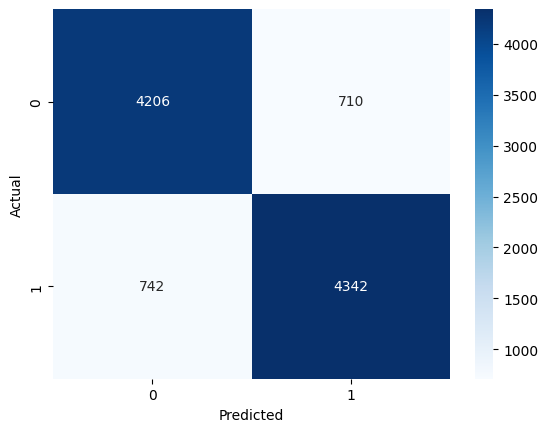

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


__Multinomial Naive Bayes gives almost Accuracy of  - 	85–86%__

*this is considered as good Baselinemodel*

### 2. __KNN (K-Nearest Neighbors)__
 __THis model is generally slow and lacks performance on sparse datasets because in larger dimensions the distances becomes unreliable..__

In [67]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.7679


In [68]:

print(classification_report(y_test, y_pred_knn))

print(confusion_matrix(y_test, y_pred_knn))

              precision    recall  f1-score   support

    negative       0.79      0.72      0.75      4916
    positive       0.75      0.81      0.78      5084

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000

[[3538 1378]
 [ 943 4141]]


__KNN gives around 75- 80% accuracy__

### 3. __Logistic Regression__

__This is usually one of the best models for TF-IDF text data__

In [69]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8916
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4916
    positive       0.89      0.90      0.89      5084

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [70]:
print(confusion_matrix(y_test, y_pred_lr))

[[4326  590]
 [ 494 4590]]


__Hyperparameter tuning using Gridsearchcv for Logistic Regression for best model__

- C	regularization strength
- penalty	l1 or l2
- solver	optimization method

In [80]:
param_grid_lr = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2'],
    'solver':['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=3,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Logistic Regression Accuracy: 0.8916


In [81]:
print(confusion_matrix(y_test, y_pred_lr))

[[4326  590]
 [ 494 4590]]


##### __Almost we are getting same accruacy Model After GridsearchCV for Logistic Regression__

##### *Logistic Regression gives 88-89% accuracy*

### 4. __Decision Tree__

__Decision trees are not usually good for sparse TF-IDF data,just using it  for comparison.__

In [75]:
### 4. __Decision Tree__

from sklearn.tree import DecisionTreeClassifier
# Basic model
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7086
              precision    recall  f1-score   support

    negative       0.70      0.70      0.70      4916
    positive       0.71      0.72      0.71      5084

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



In [82]:
print(confusion_matrix(y_test, y_pred_dt))

[[3446 1470]
 [1444 3640]]


### 5. __SVM__

__Best model for Text classification__


In [89]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8885


In [90]:
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      4916
    positive       0.89      0.89      0.89      5084

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4340  576]
 [ 539 4545]]


#### SVM gives Almost 89% accuracy on Test data nearest to LOgistic Regression

In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid_svm = {
    'C':[0.01,0.1,1,10]
}

grid_svm = GridSearchCV(
    LinearSVC(),
    param_grid_svm,
    cv=3,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8933


In [95]:
print(best_svm)

LinearSVC(C=0.1)


In [96]:
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4916
    positive       0.89      0.91      0.90      5084

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4329  587]
 [ 480 4604]]


In [107]:
results = {
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

print("Result Comparision")
for model, score in results.items():
    print(model, ":", score)



Result Comparision
Naive Bayes : 0.8548
KNN : 0.7679
Logistic Regression : 0.8916
Decision Tree : 0.7086
SVM : 0.8933


## Best Models Description 
#### - SVM → ~89.33%
__it gives higher accuracy because High Dimensional , Sparse and linear Separable Dataset after TF-IDF. SVM tries to find a decision boundary (hyperplane) that separates classes.positive reviews → one side ,negative reviews → other side.SVM chooses the boundary with the maximum margin.This makes the model Gives accurate Results.__
#### - Logistic Regression → 89.16% 
__simialr as SVM ,it gives higher accuracy because High Dimensional , Sparse and linear Separable Dataset after TF-IDF.Logistic Regression handles this very well because it is a linear classifier. COnceptually it learns something like Postive words -> higher score and negative words ->lower score. it builds a decision boundary in high dimensional space. and gives better results.__
#### - Naive Bayes → 85%
__this works good because the Word independence assumption works reasonably well..p(class|features)=p(f1|class)*p(f2|class)----p(class) this logic works good but Logistic Regression learn Stronger Relationships that is why beats NB__

#### - KNN ->77%
__KNN performs poorly on text because:Distance calculation becomes unreliable in high dimensions.our TF-IDF gives 50000*10000 which is very high dimensions:
therfore All points look equally distant beacause of that Curse of Dimensionality occurs and model generally lacks from other models__

#### - Decision tree ->71%
__Decision Trees are not good for sparse text features because:They split features one by one ,But TF-IDF creates 10000 features, making trees unstable.__

# *Ensemble Methods(Random Forest, Gradient Boosting, XGBoost))*

#### - 6.Random FOrest

In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8546
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85      4916
    positive       0.87      0.85      0.86      5084

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

[[4250  666]
 [ 788 4296]]


#### 7. Gradient Boosting 

In [120]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.8136


In [139]:

print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))

              precision    recall  f1-score   support

    negative       0.84      0.76      0.80      4916
    positive       0.79      0.86      0.82      5084

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000

[[3753 1163]
 [ 701 4383]]


#### 8. XG BOOST

In [138]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
y_train_new=y_train.map({
    'negative':0, 'positive':1})
y_test_new=y_test.map({
    'negative':0, 'positive':1})
xgb.fit(X_train, y_train_new)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_new, y_pred_xgb))
print(classification_report(y_test_new, y_pred_xgb))
print(confusion_matrix(y_test_new, y_pred_xgb))

XGBoost Accuracy: 0.8629
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4916
           1       0.85      0.88      0.87      5084

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

[[4150  766]
 [ 605 4479]]


- Random Forest	- 0.8546
- Gradient Boosting	- 0.8136
- XGBoost	- 0.8629

__Although ensemble models are generally powerful, in this case they did not outperform Logistic Regression (0.8916) and SVM(0.833).__

this can happened because of 
- Tree-based algorithms like Random Forest and Gradient Boosting do not handle sparse high-dimensional data as efficiently as linear models.


## Final Conclusion
### __SVM and logistic Regression wins with almost 90% accuracy with TF-IDF Sparse high dimensional dataset for sentiment classifier__

### *Word Importance Visualization*

- we will print the Logistic Regression Word Importance that how top 20 positive and negative words to Classify sentiment 

In [150]:
#it contains all words weights
lr.coef_[0]

array([ 0.03125074, -0.5774728 ,  0.9580508 , ..., -0.06066418,
        0.27982001, -0.6031465 ], shape=(10000,))

In [143]:
vectorizer.get_feature_names_out()

array(['007', '010', '10', ..., 'zoom', 'zorro', 'zucco'],
      shape=(10000,), dtype=object)

In [151]:
# vectorizer creates the vocabulary 
feature_names = vectorizer.get_feature_names_out()
coefficients = svm.coef_[0]
import numpy as np

top_positive = np.argsort(coefficients)[-20:]

for i in top_positive:
    print(feature_names[i])


brilliant
superb
enjoy
best
wonderful
subtle
today
enjoyable
wonderfully
hilarious
1010
refresh
perfectly
favorite
perfect
great
910
excellent
810
710


In [152]:
top_negative = np.argsort(coefficients)[:20]

for i in top_negative:
    print(feature_names[i])

410
waste
awful
310
bad
210
worst
disappointment
poor
horrible
mediocre
fail
forgettable
poorly
dull
mst3k
terrible
disappointing
boring
laughable


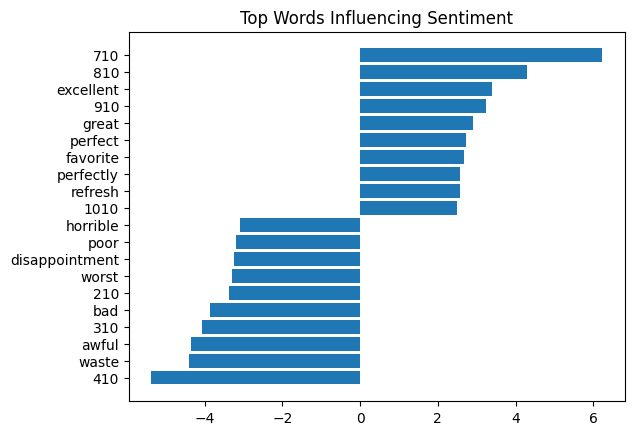

In [153]:
import matplotlib.pyplot as plt

top_pos = np.argsort(coefficients)[-10:]
top_neg = np.argsort(coefficients)[:10]

top_features = np.concatenate([top_neg, top_pos])
top_words = [feature_names[i] for i in top_features]
weights = coefficients[top_features]

plt.barh(top_words, weights)
plt.title("Top Words Influencing Sentiment")
plt.show()

In [154]:
# in dataframe format
top_pos_words = [feature_names[i] for i in top_positive]
top_neg_words = [feature_names[i] for i in top_negative]

pd.DataFrame({
    "Positive Words": top_pos_words,
    "Negative Words": top_neg_words
})

,Positive Words,Negative Words
0,brilliant,410
1,superb,waste
2,enjoy,awful
3,best,310
4,wonderful,bad
5,subtle,210
6,today,worst
7,enjoyable,disappointment
8,wonderfully,poor
9,hilarious,horrible


### SAVing Best models for creating Application



In [145]:
import pickle

In [146]:
# saving the Model svm model
pickle.dump(svm, open("sentiment_model.pkl", "wb"))

In [147]:
# saving the vectorizer as the SVM required the vector form of text
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

__Thank You__

__Created By Varun__